In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_auc_score)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Task 1: Data Loading and Understanding
We load the dataset using Pandas and look at its shape, columns, data types and statistics.

In [41]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Assigment AI 1\WA_Fn-UseC_-Telco-Customer-Churn .csv")
# Agar Excel file ho to upar wali line hata kar yeh likho:
# df = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn.xlsx")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(list(df.columns))

Shape (rows, columns): (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [44]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [45]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [46]:
print("Target variable: Churn")
print(df["Churn"].value_counts())
print()
print((df["Churn"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Target variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: str


### Important columns
- customerID: unique ID of customer (not useful for prediction)
- gender: Male / Female
- SeniorCitizen: 1 if senior citizen, otherwise 0
- Partner, Dependents: customer has a partner / dependents
- tenure: number of months the customer stayed with the company
- PhoneService, MultipleLines: phone service / more than one line
- InternetService: DSL, Fiber optic or No
- OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport: extra services
- StreamingTV, StreamingMovies: streaming services
- Contract: Month-to-month, One year, Two year
- PaperlessBilling: electronic bill or not
- PaymentMethod: how the customer pays
- MonthlyCharges: monthly bill amount
- TotalCharges: total amount billed so far
- Churn (TARGET): Yes = customer left, No = customer stayed

## Task 2: Data Preprocessing
We check missing values, duplicates, wrong data types and unnecessary columns.

In [47]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0
Duplicate rows: 0
Duplicate customerIDs: 0


In [48]:
print("TotalCharges dtype before:", df["TotalCharges"].dtype)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges dtype after :", df["TotalCharges"].dtype)
print("Missing in TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges dtype before: str
TotalCharges dtype after : float64
Missing in TotalCharges: 11


In [49]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


These 11 customers have tenure = 0 (new customers, not billed yet), so TotalCharges is unknown.
They are only 0.16% of the data, so we remove them instead of inventing values.

In [50]:
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print("New shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

New shape: (7032, 21)
Remaining missing values: 0


In [51]:
df = df.drop(columns=["customerID"])
print("Columns now:", df.shape[1])

Columns now: 20


In [52]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col:18s}", df[col].unique())

gender             <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner            <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents         <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService       <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines      <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService    <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity     <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup       <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection   <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport        <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV        <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies    <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype

In [53]:
cols_internet = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
for col in cols_internet:
    df[col] = df[col].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

print(df["MultipleLines"].unique(), df["OnlineSecurity"].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str <StringArray>
['No', 'Yes']
Length: 2, dtype: str


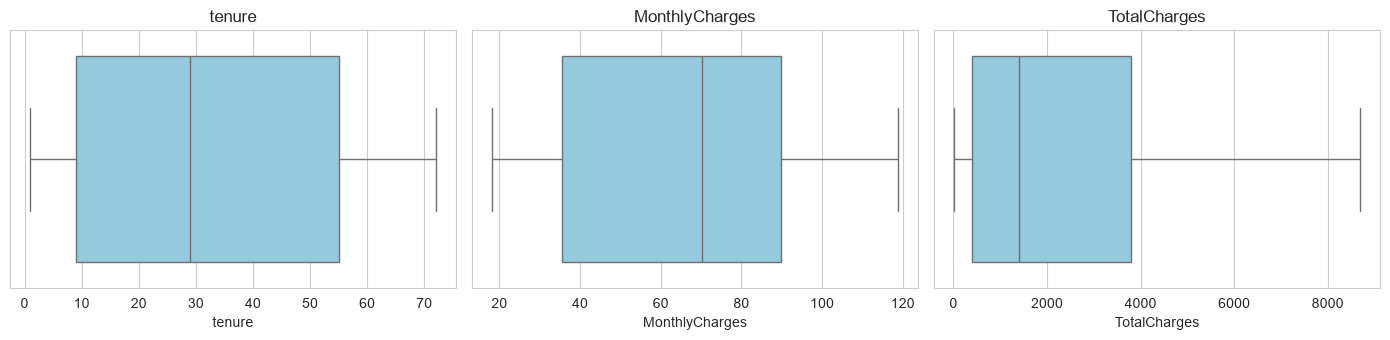

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(x=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Task 3: Exploratory Data Analysis (EDA)

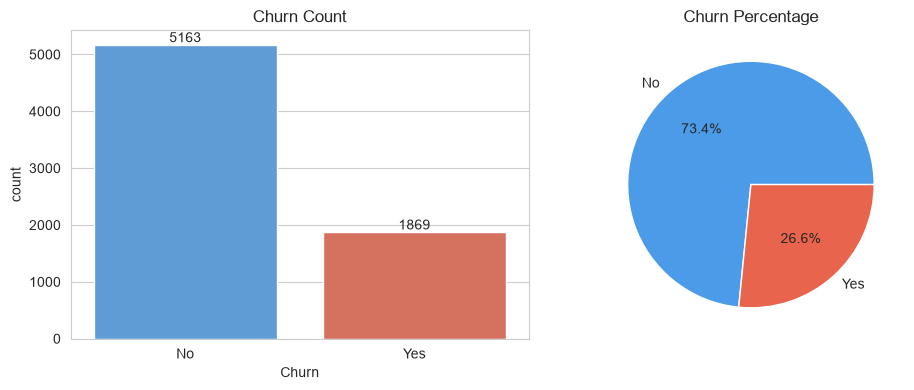

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Churn", data=df, ax=axes[0], palette=["#4c9be8", "#e8644c"])
axes[0].set_title("Churn Count")
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1],
                                    colors=["#4c9be8", "#e8644c"], ylabel="")
axes[1].set_title("Churn Percentage")
plt.tight_layout()
plt.show()

In [56]:
def churn_rate(col):
    return (df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
              .round(2).sort_values(ascending=False))

for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport", "SeniorCitizen"]:
    print(f"--- Churn rate (%) by {col} ---")
    print(churn_rate(col).to_string())
    print()

--- Churn rate (%) by Contract ---
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85

--- Churn rate (%) by InternetService ---
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43

--- Churn rate (%) by PaymentMethod ---
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25

--- Churn rate (%) by TechSupport ---
TechSupport
No     31.23
Yes    15.20

--- Churn rate (%) by SeniorCitizen ---
SeniorCitizen
1    41.68
0    23.65



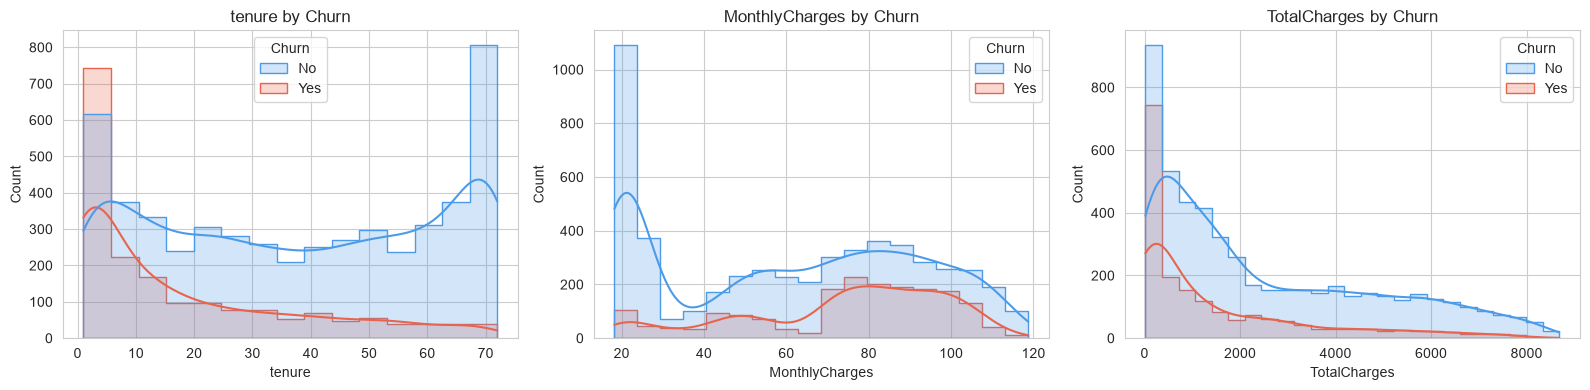

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax,
                 palette=["#4c9be8", "#e8644c"], element="step")
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

In [58]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.65,61.31,2555.34
Yes,17.98,74.44,1531.80


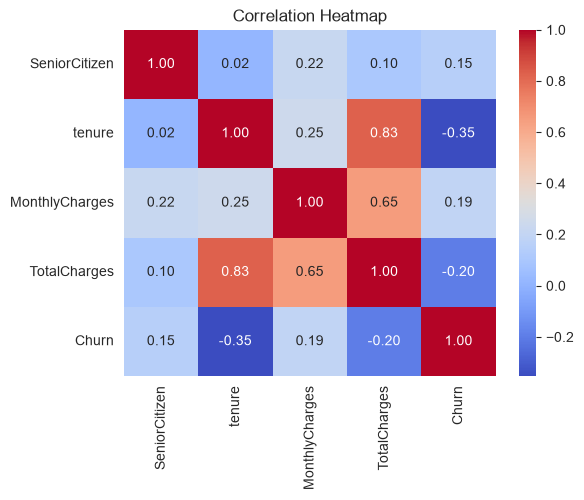

In [59]:
corr_df = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn"] = (df["Churn"] == "Yes").astype(int)
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### EDA findings
- About 73% customers stayed and 27% left (imbalanced data).
- Month-to-month contract customers churn most (about 43%); two-year contract customers churn least (about 3%).
- Fiber optic customers churn more (about 42%) than DSL (about 19%).
- Electronic check payers churn the most (about 45%).
- Customers without tech support churn more (about 31% vs 15%).
- New customers (low tenure) churn much more. Tenure has negative correlation with churn.
- Churned customers have higher monthly charges.

## Task 4: Feature Engineering and Encoding
Models understand only numbers, so we convert text columns into numbers.

In [60]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [61]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                           labels=["0-12", "13-24", "25-48", "49-72"])

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumServices"] = (df[service_cols] == "Yes").sum(axis=1)

df[["tenure", "TenureGroup", "NumServices"]].head()

,tenure,TenureGroup,NumServices
0,1,0-12,1
1,34,25-48,2
2,2,0-12,2
3,45,25-48,3
4,2,0-12,0


In [62]:
binary_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines",
               "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
               "StreamingTV", "StreamingMovies", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

multi_cols = ["InternetService", "Contract", "PaymentMethod", "TenureGroup"]
df_encoded = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7032, 28)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,NumServices,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,1,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,2,0,0,1,0,0,0,1,0,1,0
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,2,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,3,0,0,1,0,0,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,0,1,0,0,0,0,1,0,0,0,0


In [63]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(list(X.columns))

X shape: (7032, 27)
y shape: (7032,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_13-24', 'TenureGroup_25-48', 'TenureGroup_49-72']


Yes/No columns were converted to 0/1. Columns with 3 or more categories use One-Hot Encoding
(0,1,2 would wrongly show an order). TenureGroup and NumServices are new features.
X = input features, y = target (Churn).

## Task 5: Training and Testing

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape, " Testing set:", X_test.shape)
print("Churn ratio in train:", round(y_train.mean(), 3), "| in test:", round(y_test.mean(), 3))

Training set: (5625, 27)  Testing set: (1407, 27)
Churn ratio in train: 0.266 | in test: 0.266


In [65]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                            class_weight="balanced", random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.


## Task 6: Model Evaluation
- Accuracy: share of all predictions that are correct.
- Precision: of customers predicted to churn, how many really churned.
- Recall: of customers who really churned, how many we caught.
- F1-score: balance between precision and recall.
- Confusion matrix: table of correct and wrong predictions (TN, FP, FN, TP).

In [66]:
results = []
predictions = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7221,0.4860,0.7914,0.6022,0.8341
Decision Tree,0.7058,0.4681,0.7834,0.5860,0.8179
Random Forest,0.7420,0.5093,0.8075,0.6246,0.8412


In [67]:
for name, y_pred in predictions.items():
    print("=" * 55)
    print(name)
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.90      0.68      0.77      1033
       Churn       0.47      0.78      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.72      1407

Random Forest
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1033
       Churn       0.51      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80   

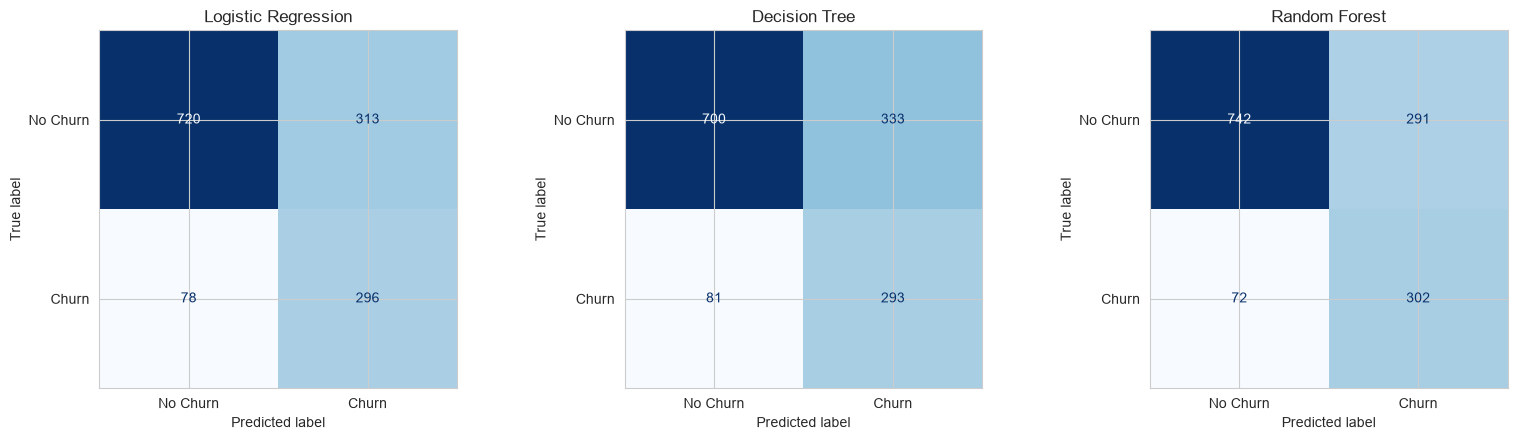

Logistic Regression  TN=720  FP=313  FN=78  TP=296
Decision Tree        TN=700  FP=333  FN=81  TP=293
Random Forest        TN=742  FP=291  FN=72  TP=302


In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

for name, y_pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name:20s} TN={tn}  FP={fp}  FN={fn}  TP={tp}")

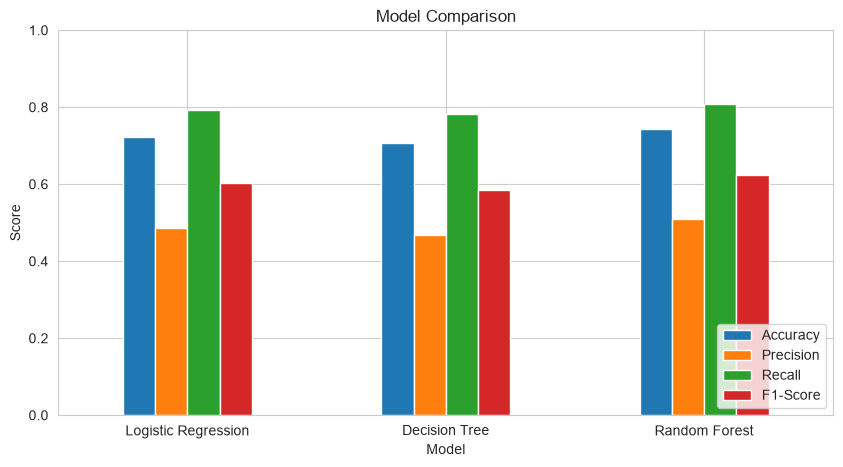

In [69]:
results_df[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

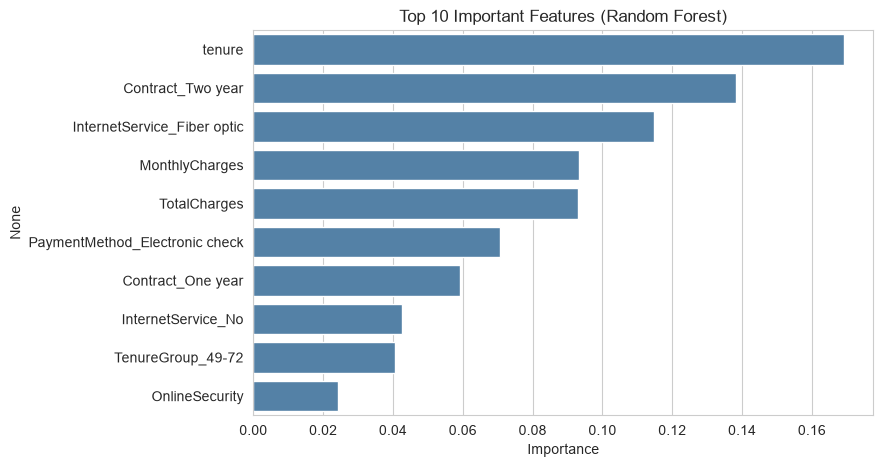

In [70]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [71]:
best_name = results_df["F1-Score"].idxmax()
final_model = models[best_name]
print("Best model (highest F1-Score):", best_name)
results_df.loc[best_name]

Best model (highest F1-Score): Random Forest


Accuracy     0.7420
Precision    0.5093
Recall       0.8075
F1-Score     0.6246
ROC-AUC      0.8412
Name: Random Forest, dtype: float64

### Model comparison
Random Forest performs best (highest accuracy, precision and F1). It combines many decision trees,
so it overfits less than a single tree and captures non-linear patterns. Logistic Regression has
similar recall but lower precision. Because only about 27% customers churn, accuracy alone is not
enough, so the final model is chosen using F1-score and recall.

## Task 7: Prediction on New Customers
The function takes raw customer information, applies the same preprocessing and encoding used in
training, and outputs Churn / No Churn with the probability.

In [72]:
def predict_churn(customer, model=final_model):
    c = pd.DataFrame([customer])

    # same cleaning as training
    c["MultipleLines"] = c["MultipleLines"].replace("No phone service", "No")
    for col in service_cols:
        c[col] = c[col].replace("No internet service", "No")

    # same feature engineering
    c["TenureGroup"] = pd.cut(c["tenure"], bins=[-1, 12, 24, 48, 72],
                              labels=["0-12", "13-24", "25-48", "49-72"])
    c["NumServices"] = (c[service_cols] == "Yes").sum(axis=1)

    # same encoding
    for col in binary_cols:
        c[col] = c[col].map({"Yes": 1, "No": 0})
    c["gender"] = c["gender"].map({"Male": 1, "Female": 0})
    c = pd.get_dummies(c, columns=multi_cols, drop_first=True, dtype=int)

    # columns ko training columns jaisa banao
    c = c.reindex(columns=X.columns, fill_value=0)

    pred = model.predict(c)[0]
    prob = model.predict_proba(c)[0][1]
    return ("Churn" if pred == 1 else "No Churn"), prob

In [73]:
customer_1 = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.5, "TotalCharges": 191.0}

customer_2 = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
    "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
    "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Two year", "PaperlessBilling": "No",
    "PaymentMethod": "Credit card (automatic)", "MonthlyCharges": 64.0, "TotalCharges": 3840.0}

for i, cust in enumerate([customer_1, customer_2], start=1):
    label, prob = predict_churn(cust)
    print(f"Customer {i}: Prediction = {label:9s} | Probability of churn = {prob:.2%}")

Customer 1: Prediction = Churn     | Probability of churn = 71.17%
Customer 2: Prediction = No Churn  | Probability of churn = 11.96%


In [74]:
sample = X_test.sample(5, random_state=1)
pred = final_model.predict(sample)
prob = final_model.predict_proba(sample)[:, 1]
pd.DataFrame({"Actual": y_test.loc[sample.index].map({1: "Churn", 0: "No Churn"}),
              "Predicted": pd.Series(pred, index=sample.index).map({1: "Churn", 0: "No Churn"}),
              "Churn Probability": prob.round(3)})

,Actual,Predicted,Churn Probability
458,No Churn,No Churn,0.354
3322,No Churn,No Churn,0.443
5096,No Churn,No Churn,0.040
5081,No Churn,Churn,0.590
3371,No Churn,No Churn,0.018


## Final Conclusion
**Best model:** Random Forest (Accuracy about 0.75, Recall about 0.78, F1 about 0.62).

**Observations:** Month-to-month contract, fiber optic internet, electronic check payment,
no tech support and short tenure all mean higher churn. About 27% customers churn.

**Limitations:** Precision is only about 0.52 so there are many false alarms. The dataset is small
(about 7,000 customers) and has no complaint or competitor data. No hyperparameter tuning was done.
Correlation does not mean causation.

**Business use:** The company can score customers every month and rank them by churn probability.
The retention team can then give offers (discount, contract upgrade, free tech support) to the
highest-risk customers, because keeping a customer costs less than losing one.